# 🛒 Customer Purchase Behaviour — Exploratory Data Analysis

**Author:** Aaryan Gupta  
**Tools:** Python · Pandas · NumPy · Matplotlib · Seaborn · Scikit-learn  

---

## Problem Statement

Retail businesses often struggle to identify *who* their most valuable customers are, *what* they buy, and *where* growth opportunities lie. This analysis explores a customer purchase dataset to uncover behavioural patterns across demographics, regions, product categories, and loyalty tiers.

**Key Questions We Answer:**
1. What does the typical customer look like (age, gender, education)?
2. Which regions and product categories drive the most revenue?
3. Do loyalty programmes actually increase spending?
4. Can we segment customers into actionable groups?

---

## 1. Import Libraries

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

## 2. Load Dataset

In [3]:
df = pd.read_csv('customer_data.csv')

print(f'Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'\nColumns: {list(df.columns)}')
df.head(10)

Dataset shape: 100,000 rows × 12 columns

Columns: ['id', 'age', 'gender', 'income', 'education', 'region', 'loyalty_status', 'purchase_frequency', 'purchase_amount', 'product_category', 'promotion_usage', 'satisfaction_score']


,id,age,gender,income,education,region,loyalty_status,purchase_frequency,purchase_amount,product_category,promotion_usage,satisfaction_score
0,1,27,Male,40682,Bachelor,East,Gold,frequent,18249,Books,0,6
1,2,29,Male,15317,Masters,West,Regular,rare,4557,Clothing,1,6
2,3,37,Male,38849,Bachelor,West,Silver,rare,11822,Clothing,0,6
3,4,30,Male,11568,HighSchool,South,Regular,frequent,4098,Food,0,7
4,5,31,Female,46952,College,North,Regular,occasional,19685,Clothing,1,5
5,6,38,Male,7347,Bachelor,South,Silver,occasional,2822,Electronics,0,5
6,7,32,Female,8265,Bachelor,South,Silver,frequent,3293,Clothing,0,7
7,8,24,Female,47773,HighSchool,North,Regular,rare,21794,Books,0,5
8,9,27,Male,19154,College,East,Regular,occasional,5819,Clothing,0,5
9,10,28,Female,24666,HighSchool,North,Regular,rare,8779,Food,0,6


## 3. Data Cleaning & Quality Assessment

In [9]:
# ── 3.1 Data types and basic info ──
print('=== Data Types ===')
print(df.dtypes)

=== Data Types ===
id                     int64
age                    int64
gender                object
income                 int64
education             object
region                object
loyalty_status        object
purchase_frequency    object
purchase_amount        int64
product_category      object
promotion_usage        int64
satisfaction_score     int64
dtype: object


In [10]:
# ── 3.2 Missing values audit ──
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_report = missing_report[missing_report['Missing Count'] > 0]

if missing_report.empty:
    print('No missing values found in any column.')
else:
    print('Missing values: ')
    print(missing_report)
    # For numeric cols use median; for categorical use mode
    for col in missing_report.index:
        if df[col].dtype in ['float64', 'int64']:
            df[col].fillna(df[col].median(), inplace=True)
        else:
            df[col].fillna(df[col].mode()[0], inplace=True)
    print('\n Missing values handled.')

No missing values found in any column.


In [11]:
# ── 3.3 Duplicate rows ──
n_dupes = df.duplicated().sum()
print(f'Duplicate rows found: {n_dupes}')
if n_dupes > 0:
    df.drop_duplicates(inplace=True)
    print(f'Duplicates removed. New shape: {df.shape}')
else:
    print(' No duplicates. Dataset is clean.')

Duplicate rows found: 0
 No duplicates. Dataset is clean.


In [12]:
# ── 3.4 Outlier detection using IQR on numeric columns ──
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print('Outlier summary (IQR method):\n')
print(f'{"Column":<25} {"Lower Bound":>12} {"Upper Bound":>12} {"Outliers":>10} {"Outlier %":>10}')
print('-' * 75)
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    pct = round(n_out / len(df) * 100, 2)
    print(f'{col:<25} {lower:>12.2f} {upper:>12.2f} {n_out:>10} {pct:>9.2f}%')

Outlier summary (IQR method):

Column                     Lower Bound  Upper Bound   Outliers  Outlier %
---------------------------------------------------------------------------
id                           -49998.50    149999.50          0      0.00%
age                              18.00        42.00        513      0.51%
income                       -17441.50     72460.50          0      0.00%
purchase_amount               -6067.50     25000.50          2      0.00%
promotion_usage                  -1.50         2.50          0      0.00%
satisfaction_score                1.00         9.00          2      0.00%


In [13]:
# ── 3.5 Categorical value consistency check ──
cat_cols = df.select_dtypes(include='object').columns.tolist()
print('Unique values per categorical column:\n')
for col in cat_cols:
    vals = df[col].unique()
    print(f'  {col}: {sorted(vals)}')

Unique values per categorical column:

  gender: ['Female', 'Male']
  education: ['Bachelor', 'College', 'HighSchool', 'Masters']
  region: ['East', 'North', 'South', 'West']
  loyalty_status: ['Gold', 'Regular', 'Silver']
  purchase_frequency: ['frequent', 'occasional', 'rare']
  product_category: ['Beauty', 'Books', 'Clothing', 'Electronics', 'Food', 'Health', 'Home']


In [15]:
# ── 3.6 Clean dataset snapshot ──
print('Cleaned Dataset Summary')
df.describe().round(2)

Cleaned Dataset Summary


,id,age,income,purchase_amount,promotion_usage,satisfaction_score
count,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00
mean,50000.50,30.00,27516.27,9634.79,0.30,5.01
std,28867.66,4.48,12996.78,4799.34,0.46,1.04
min,1.00,12.00,5000.00,1118.00,0.00,0.00
25%,25000.75,27.00,16271.75,5583.00,0.00,4.00
50%,50000.50,30.00,27584.50,9452.00,0.00,5.00
75%,75000.25,33.00,38747.25,13350.00,1.00,6.00
max,100000.00,49.00,50000.00,26204.00,1.00,10.00


## 4. Univariate Analysis — Understanding Individual Features

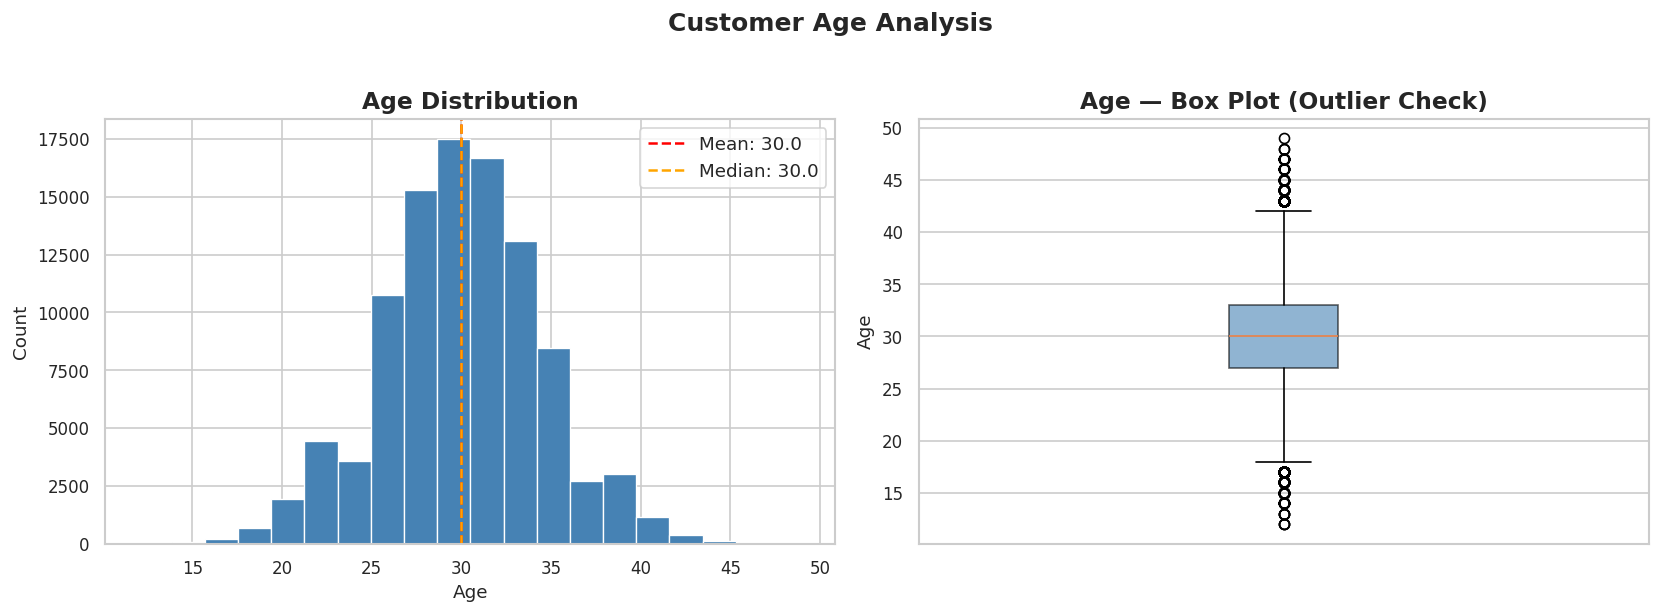


 Age Stats → Mean: 30.0 | Median: 30.0 | Std Dev: 4.5
   Range: 12 – 49


In [18]:
# ── 4.1 Age distribution ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['age'], bins=20, color='steelblue', edgecolor='white', linewidth=0.8)
axes[0].axvline(df['age'].mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean: {df["age"].mean():.1f}')
axes[0].axvline(df['age'].median(), color='orange', linestyle='--', linewidth=1.5, label=f'Median: {df["age"].median():.1f}')
axes[0].set_title('Age Distribution')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')
axes[0].legend()

# Box plot
axes[1].boxplot(df['age'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('Age — Box Plot (Outlier Check)')
axes[1].set_ylabel('Age')
axes[1].set_xticks([])

plt.suptitle('Customer Age Analysis', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'\n Age Stats → Mean: {df["age"].mean():.1f} | Median: {df["age"].median():.1f} | Std Dev: {df["age"].std():.1f}')
print(f'   Range: {df["age"].min()} – {df["age"].max()}')

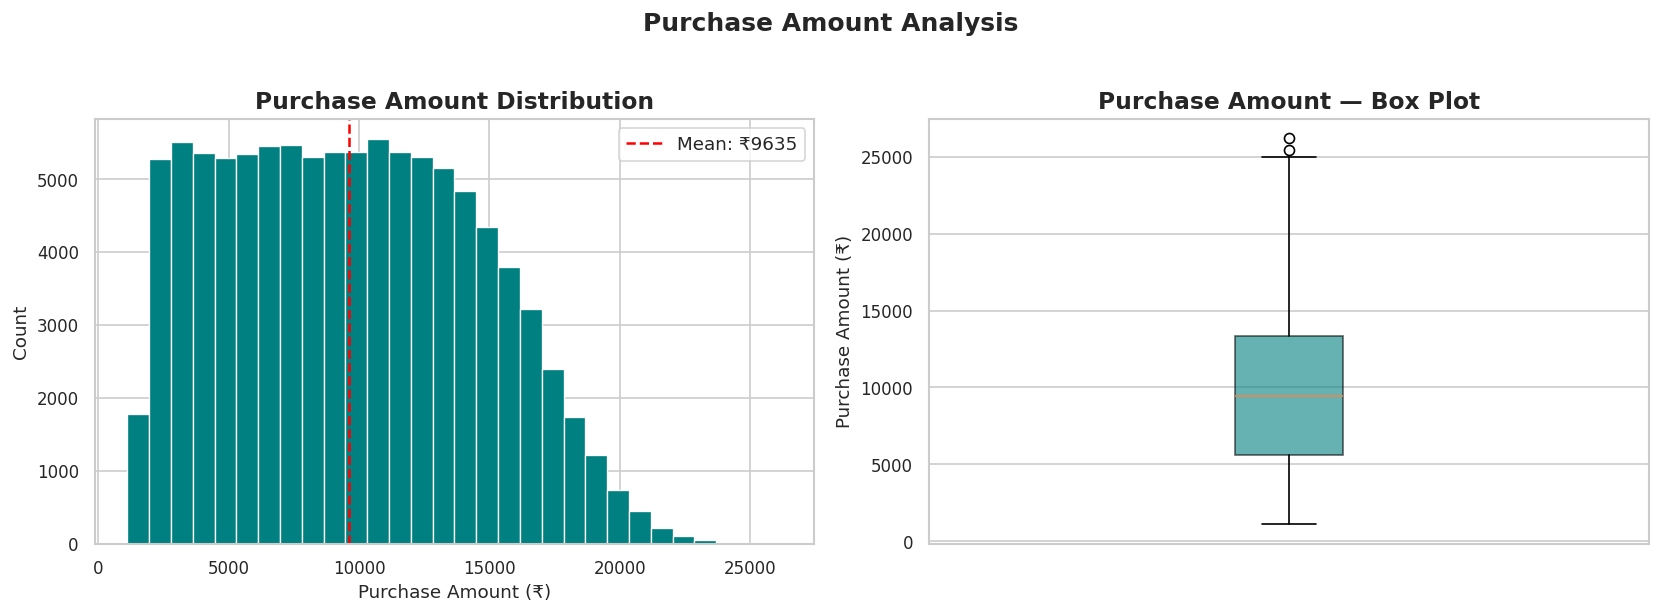


 Purchase Stats → Mean: ₹9634.79 | Median: ₹9452.00
   Total Revenue: ₹963,479,084
   Top 10% customers spend above: ₹16199.00


In [20]:
# ── 4.2 Purchase amount distribution ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['purchase_amount'], bins=30, color='teal', edgecolor='white', linewidth=0.8)
axes[0].axvline(df['purchase_amount'].mean(), color='red', linestyle='--', linewidth=1.5,
                label=f'Mean: ₹{df["purchase_amount"].mean():.0f}')
axes[0].set_title('Purchase Amount Distribution')
axes[0].set_xlabel('Purchase Amount (₹)')
axes[0].set_ylabel('Count')
axes[0].legend()

axes[1].boxplot(df['purchase_amount'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='teal', alpha=0.6))
axes[1].set_title('Purchase Amount — Box Plot')
axes[1].set_ylabel('Purchase Amount (₹)')
axes[1].set_xticks([])

plt.suptitle('Purchase Amount Analysis', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'\n Purchase Stats → Mean: ₹{df["purchase_amount"].mean():.2f} | Median: ₹{df["purchase_amount"].median():.2f}')
print(f'   Total Revenue: ₹{df["purchase_amount"].sum():,.0f}')
print(f'   Top 10% customers spend above: ₹{df["purchase_amount"].quantile(0.9):.2f}')

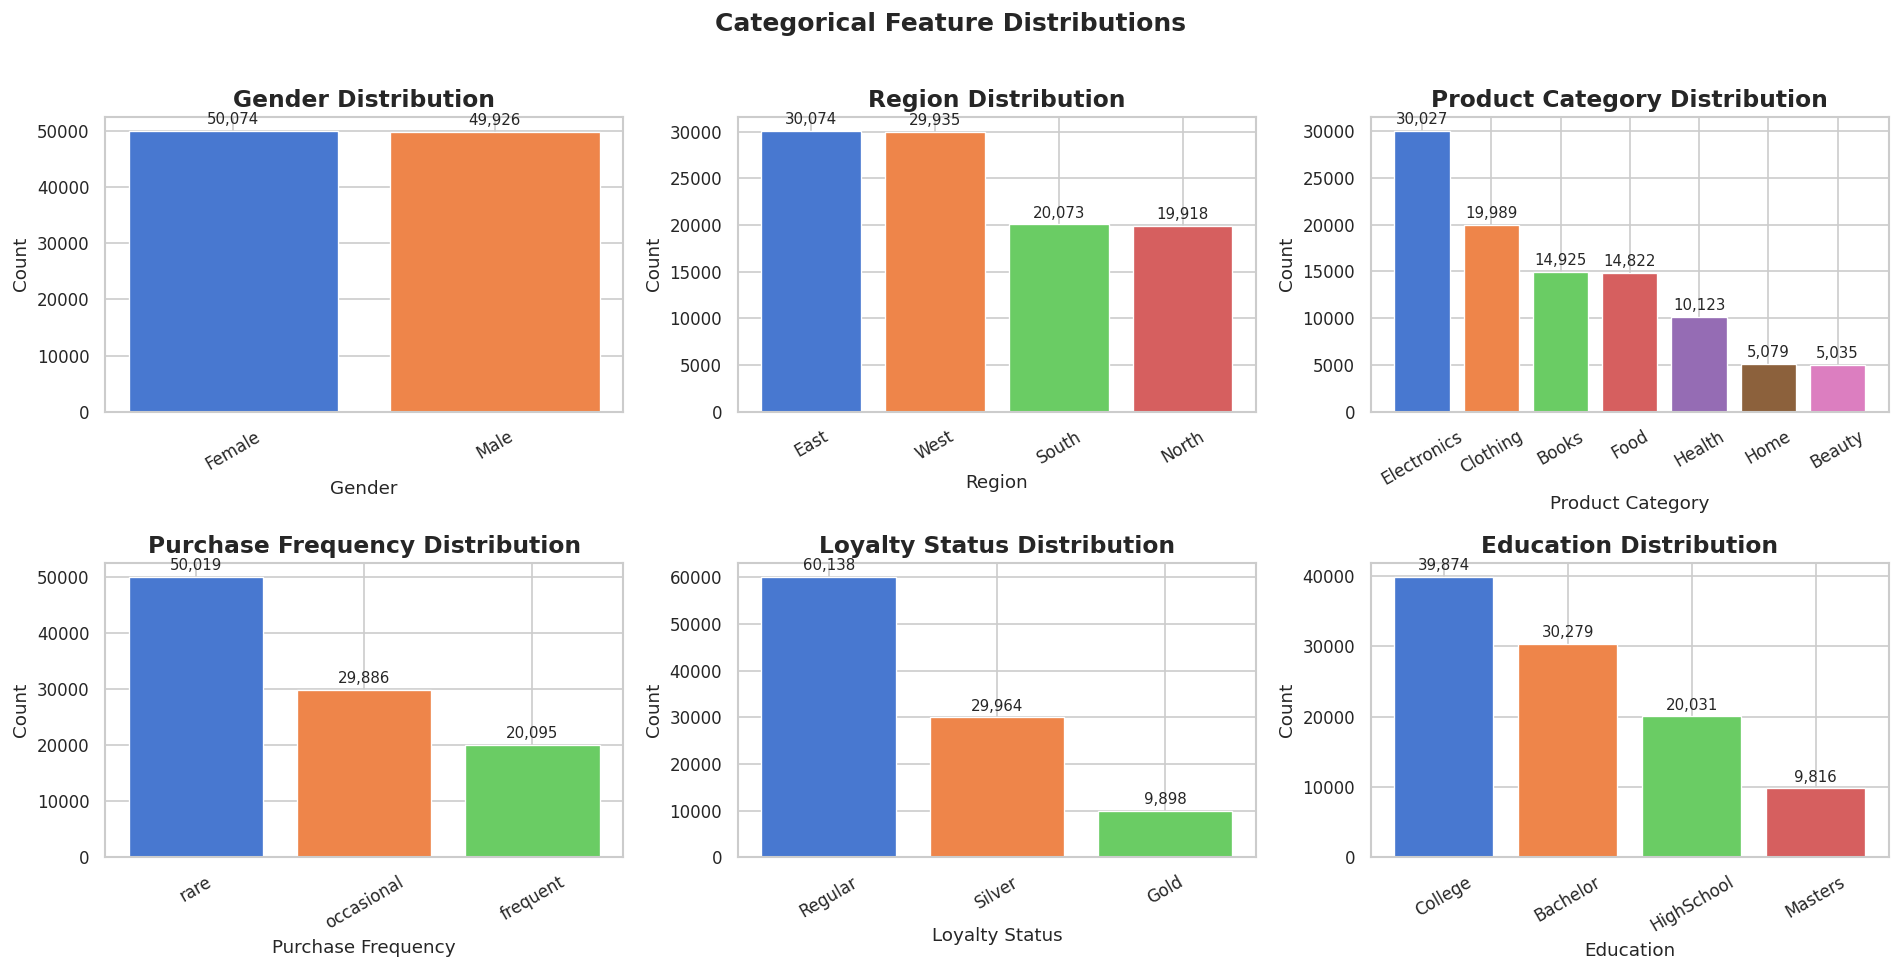

In [21]:
# ── 4.3 Categorical distributions ──
cat_to_plot = ['gender', 'region', 'product_category', 'purchase_frequency', 'loyalty_status', 'education']
cat_to_plot = [c for c in cat_to_plot if c in df.columns]

n = len(cat_to_plot)
cols = 3
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 4))
axes = axes.flatten()

colors = sns.color_palette('muted', 10)

for i, col in enumerate(cat_to_plot):
    counts = df[col].value_counts()
    bars = axes[i].bar(counts.index, counts.values,
                       color=colors[:len(counts)], edgecolor='white', linewidth=0.8)
    axes[i].set_title(f'{col.replace("_", " ").title()} Distribution')
    axes[i].set_xlabel(col.replace('_', ' ').title())
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=30)
    for bar in bars:
        h = bar.get_height()
        axes[i].annotate(f'{h:,}', xy=(bar.get_x() + bar.get_width()/2, h),
                         xytext=(0, 4), textcoords='offset points', ha='center', fontsize=9)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Categorical Feature Distributions', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 5. Bivariate Analysis — Revenue & Spending Patterns

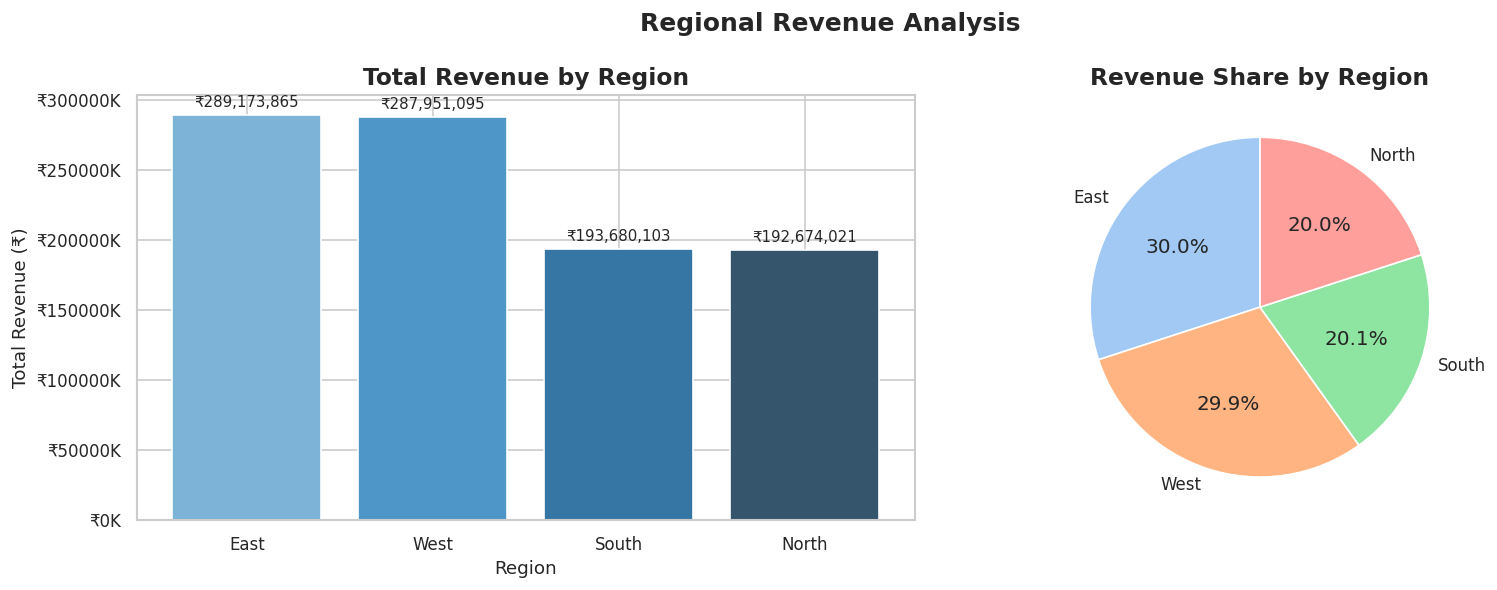


 Region Summary:
Region  Total Revenue  Avg Purchase  Customer Count  Revenue Share %
  East      289173865   9615.410820           30074             30.0
  West      287951095   9619.211458           29935             29.9
 South      193680103   9648.787077           20073             20.1
 North      192674021   9673.361834           19918             20.0


In [22]:
# ── 5.1 Revenue by region ──
region_rev = df.groupby('region')['purchase_amount'].agg(['sum', 'mean', 'count']).reset_index()
region_rev.columns = ['Region', 'Total Revenue', 'Avg Purchase', 'Customer Count']
region_rev['Revenue Share %'] = (region_rev['Total Revenue'] / region_rev['Total Revenue'].sum() * 100).round(1)
region_rev = region_rev.sort_values('Total Revenue', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bars = axes[0].bar(region_rev['Region'], region_rev['Total Revenue'],
                   color=sns.color_palette('Blues_d', len(region_rev)), edgecolor='white')
axes[0].set_title('Total Revenue by Region')
axes[0].set_xlabel('Region')
axes[0].set_ylabel('Total Revenue (₹)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1000:.0f}K'))
for bar in bars:
    h = bar.get_height()
    axes[0].annotate(f'₹{h:,.0f}', xy=(bar.get_x() + bar.get_width()/2, h),
                     xytext=(0, 5), textcoords='offset points', ha='center', fontsize=9)

axes[1].pie(region_rev['Total Revenue'], labels=region_rev['Region'],
            autopct='%1.1f%%', startangle=90,
            colors=sns.color_palette('pastel', len(region_rev)))
axes[1].set_title('Revenue Share by Region')

plt.suptitle('Regional Revenue Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n Region Summary:')
print(region_rev.to_string(index=False))

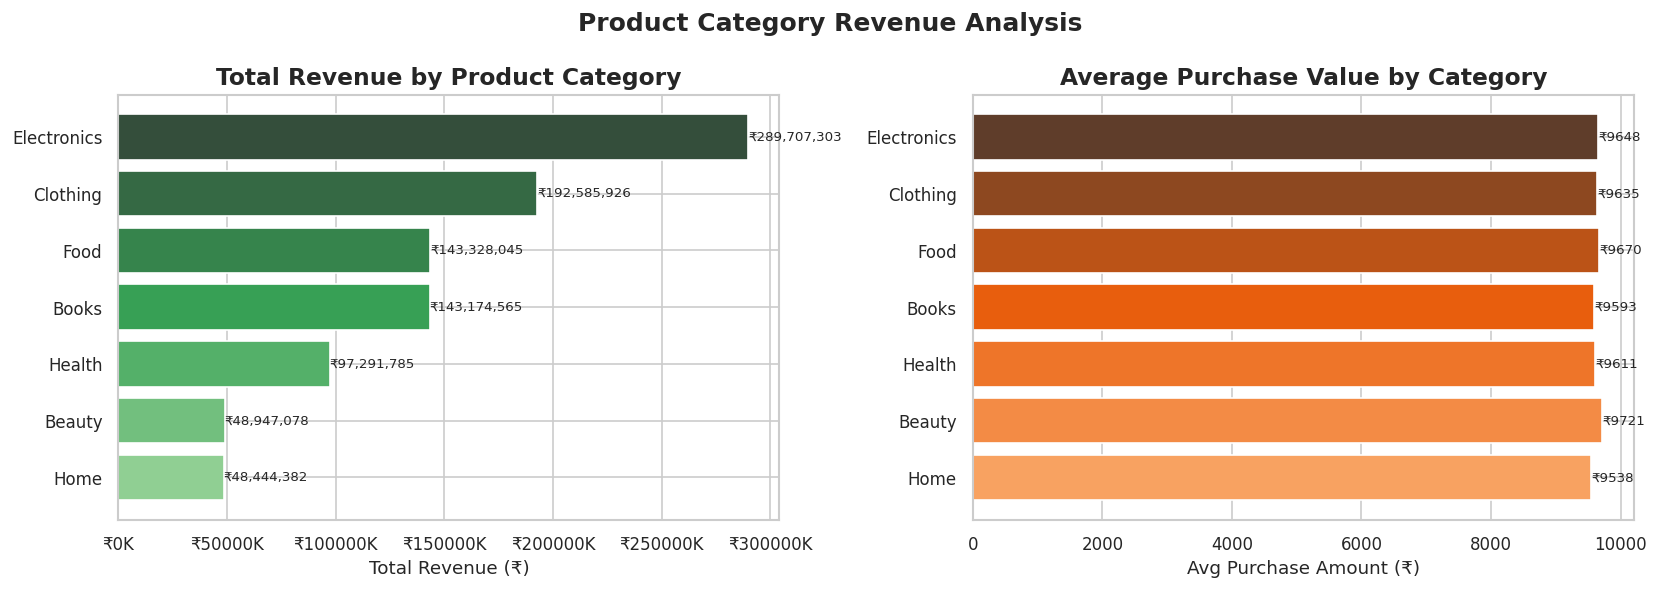

In [23]:
# ── 5.2 Revenue by product category ──
cat_rev = df.groupby('product_category')['purchase_amount'].agg(['sum', 'mean', 'count']).reset_index()
cat_rev.columns = ['Category', 'Total Revenue', 'Avg Purchase', 'Transactions']
cat_rev = cat_rev.sort_values('Total Revenue', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(cat_rev['Category'], cat_rev['Total Revenue'],
             color=sns.color_palette('Greens_d', len(cat_rev)))
axes[0].set_title('Total Revenue by Product Category')
axes[0].set_xlabel('Total Revenue (₹)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1000:.0f}K'))
for i, (val, name) in enumerate(zip(cat_rev['Total Revenue'], cat_rev['Category'])):
    axes[0].text(val + 100, i, f'₹{val:,.0f}', va='center', fontsize=8)

axes[1].barh(cat_rev['Category'], cat_rev['Avg Purchase'],
             color=sns.color_palette('Oranges_d', len(cat_rev)))
axes[1].set_title('Average Purchase Value by Category')
axes[1].set_xlabel('Avg Purchase Amount (₹)')
for i, val in enumerate(cat_rev['Avg Purchase']):
    axes[1].text(val + 5, i, f'₹{val:.0f}', va='center', fontsize=8)

plt.suptitle('Product Category Revenue Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

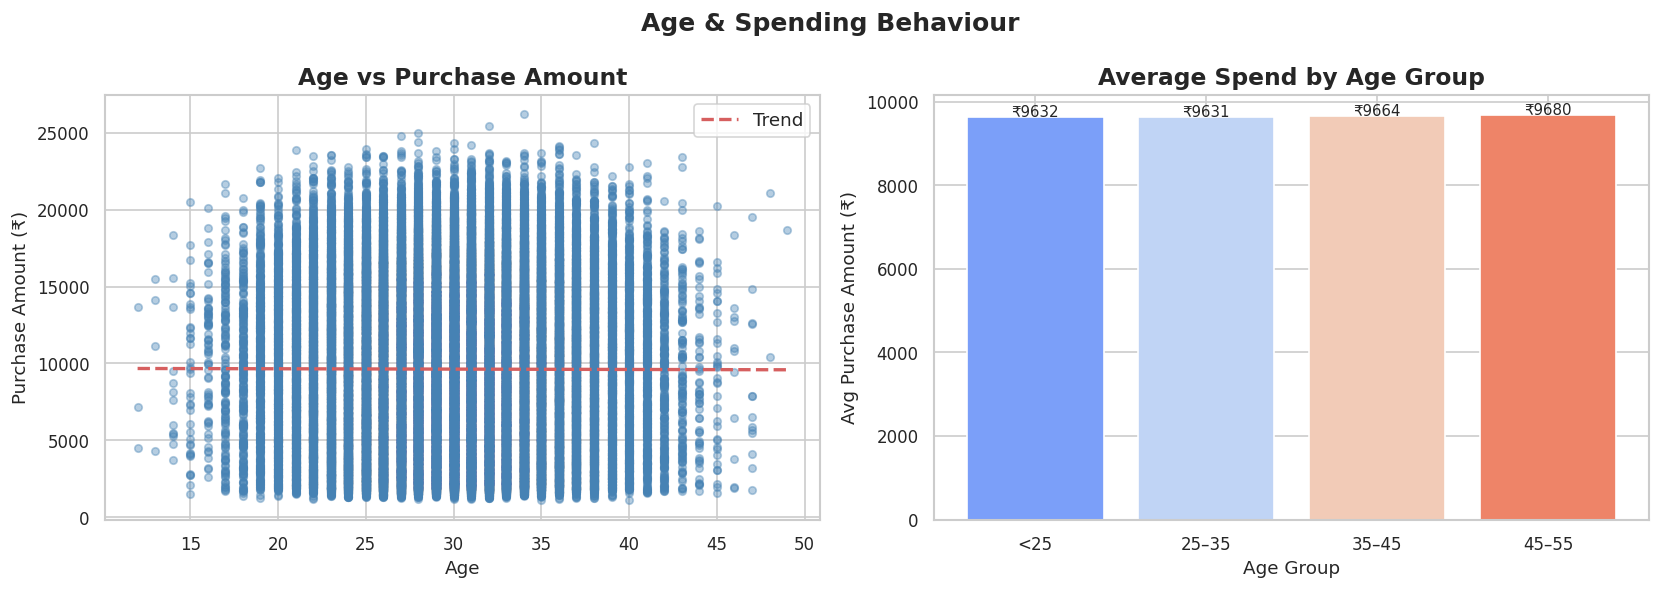


 Pearson Correlation (Age vs Purchase Amount): -0.0021
   Interpretation: Weak correlation


In [25]:
# ── 5.3 Age vs Purchase Amount ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter
axes[0].scatter(df['age'], df['purchase_amount'], alpha=0.4, s=20, color='steelblue')
# Trend line
z = np.polyfit(df['age'], df['purchase_amount'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['age'].min(), df['age'].max(), 100)
axes[0].plot(x_line, p(x_line), 'r--', linewidth=2, label='Trend')
axes[0].set_title('Age vs Purchase Amount')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Purchase Amount (₹)')
axes[0].legend()

# Age bins
df['age_group'] = pd.cut(df['age'], bins=[0, 25, 35, 45, 55, 100],
                          labels=['<25', '25–35', '35–45', '45–55', '55+'])
age_spend = df.groupby('age_group', observed=True)['purchase_amount'].mean().reset_index()
axes[1].bar(age_spend['age_group'].astype(str), age_spend['purchase_amount'],
            color=sns.color_palette('coolwarm', len(age_spend)))
axes[1].set_title('Average Spend by Age Group')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Avg Purchase Amount (₹)')
for i, val in enumerate(age_spend['purchase_amount']):
    axes[1].text(i, val + 5, f'₹{val:.0f}', ha='center', fontsize=9)

plt.suptitle('Age & Spending Behaviour', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

corr = df['age'].corr(df['purchase_amount'])
print(f'\n Pearson Correlation (Age vs Purchase Amount): {corr:.4f}')
print('   Interpretation:', 'Weak' if abs(corr) < 0.3 else 'Moderate' if abs(corr) < 0.6 else 'Strong',
      'correlation')

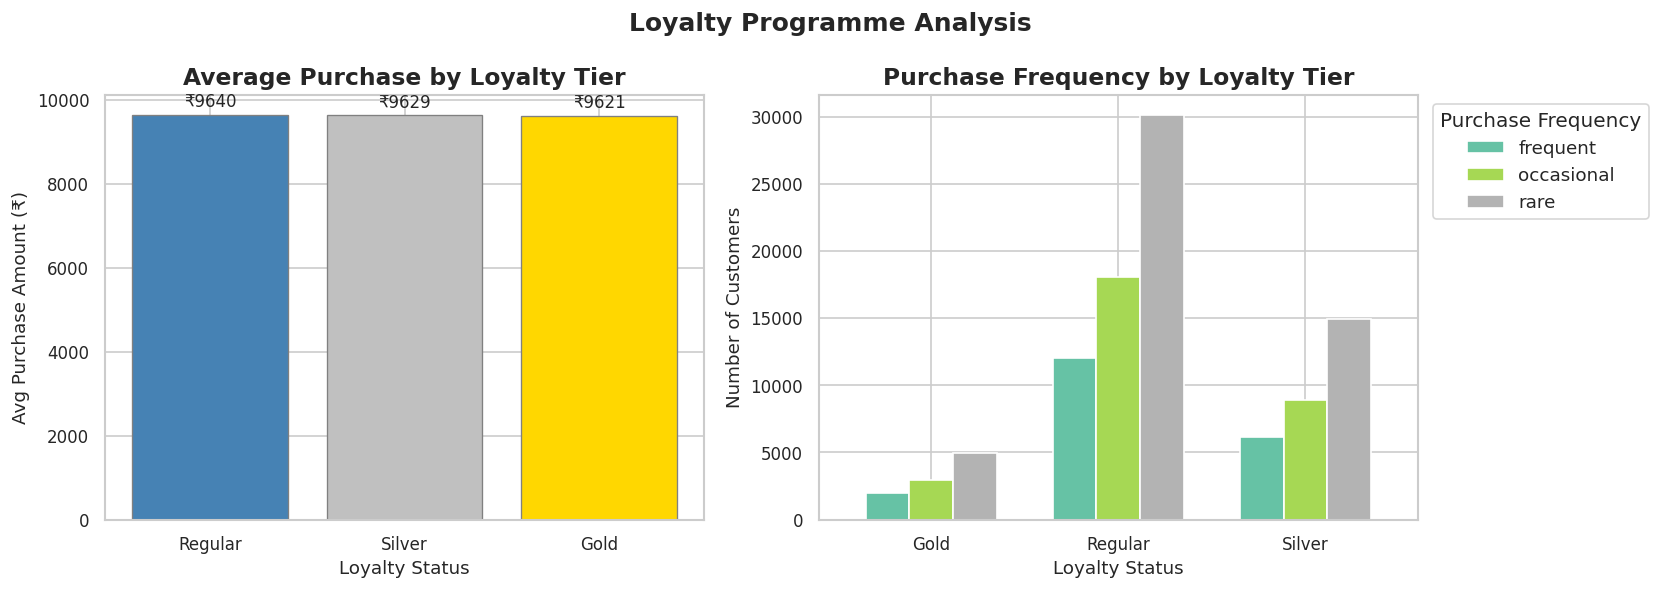


 Loyalty Stats:
Loyalty Status  Avg Purchase  Total Revenue  Customers
       Regular   9639.976537      579728909      60138
        Silver   9628.777566      288516691      29964
          Gold   9621.487573       95233484       9898


In [27]:
# ── 5.4 Loyalty programme effectiveness ──
loyalty_stats = df.groupby('loyalty_status')['purchase_amount'].agg(['mean', 'sum', 'count']).reset_index()
loyalty_stats.columns = ['Loyalty Status', 'Avg Purchase', 'Total Revenue', 'Customers']
loyalty_stats = loyalty_stats.sort_values('Avg Purchase', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

palette = {'Gold': 'gold', 'Silver': 'silver', 'Regular': 'steelblue'}
colors_list = [palette.get(s, 'gray') for s in loyalty_stats['Loyalty Status']]

bars = axes[0].bar(loyalty_stats['Loyalty Status'], loyalty_stats['Avg Purchase'],
                   color=colors_list, edgecolor='gray', linewidth=0.8)
axes[0].set_title('Average Purchase by Loyalty Tier')
axes[0].set_xlabel('Loyalty Status')
axes[0].set_ylabel('Avg Purchase Amount (₹)')
for bar in bars:
    h = bar.get_height()
    axes[0].annotate(f'₹{h:.0f}', xy=(bar.get_x() + bar.get_width()/2, h),
                     xytext=(0, 5), textcoords='offset points', ha='center', fontsize=10)

freq_loyalty = df.groupby(['loyalty_status', 'purchase_frequency']).size().unstack(fill_value=0)
freq_loyalty.plot(kind='bar', ax=axes[1], colormap='Set2', edgecolor='white', width=0.7)
axes[1].set_title('Purchase Frequency by Loyalty Tier')
axes[1].set_xlabel('Loyalty Status')
axes[1].set_ylabel('Number of Customers')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Purchase Frequency', bbox_to_anchor=(1.01, 1), loc='upper left')

plt.suptitle('Loyalty Programme Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n Loyalty Stats:')
print(loyalty_stats.to_string(index=False))

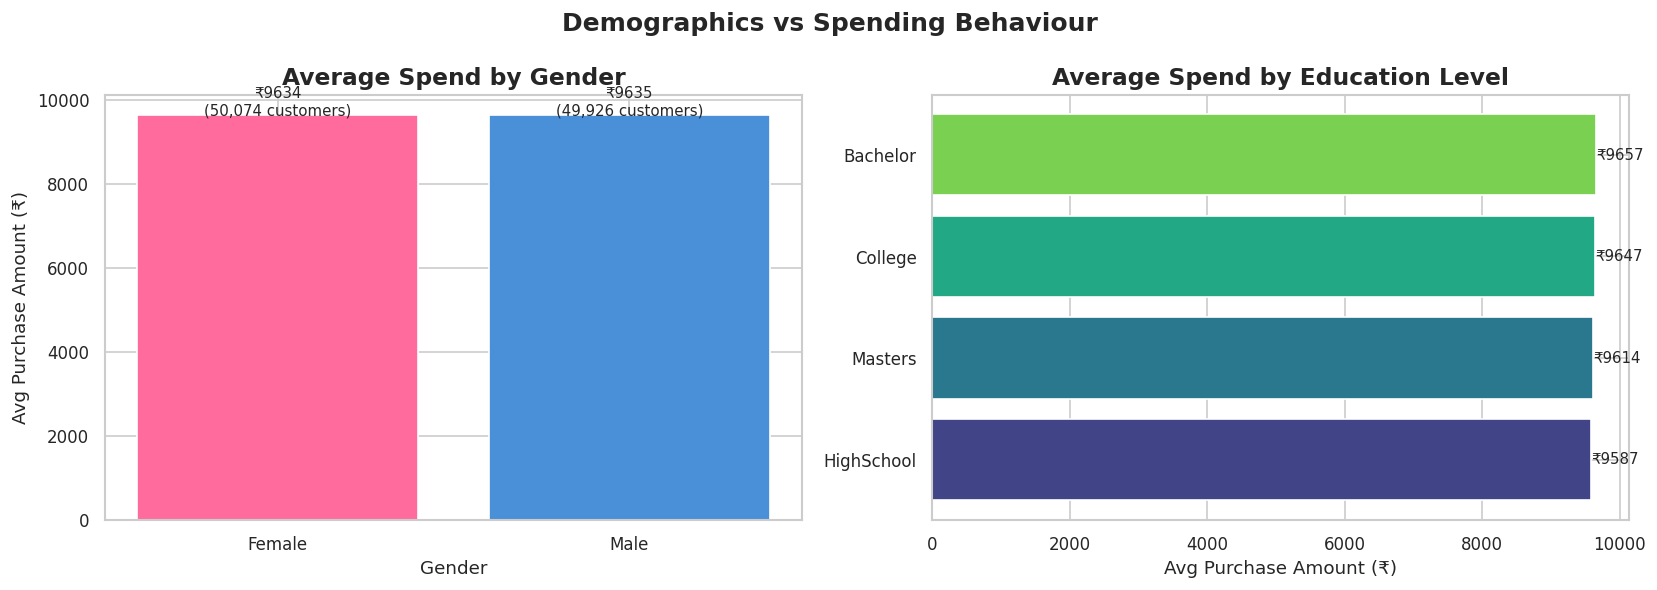

In [28]:
# ── 5.5 Gender & Education spending patterns ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gender
gender_spend = df.groupby('gender')['purchase_amount'].agg(['mean', 'sum', 'count']).reset_index()
gender_colors = ['#FF6B9D', '#4A90D9'] if 'Female' in gender_spend['gender'].values else sns.color_palette('pastel')
axes[0].bar(gender_spend['gender'], gender_spend['mean'],
            color=gender_colors[:len(gender_spend)], edgecolor='white')
axes[0].set_title('Average Spend by Gender')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Avg Purchase Amount (₹)')
for i, (g, m) in enumerate(zip(gender_spend['gender'], gender_spend['mean'])):
    axes[0].text(i, m + 5, f'₹{m:.0f}\n({gender_spend["count"].iloc[i]:,} customers)',
                 ha='center', fontsize=9)

# Education
edu_spend = df.groupby('education')['purchase_amount'].mean().sort_values(ascending=True)
axes[1].barh(edu_spend.index, edu_spend.values,
             color=sns.color_palette('viridis', len(edu_spend)))
axes[1].set_title('Average Spend by Education Level')
axes[1].set_xlabel('Avg Purchase Amount (₹)')
for i, val in enumerate(edu_spend.values):
    axes[1].text(val + 5, i, f'₹{val:.0f}', va='center', fontsize=9)

plt.suptitle('Demographics vs Spending Behaviour', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Correlation Analysis

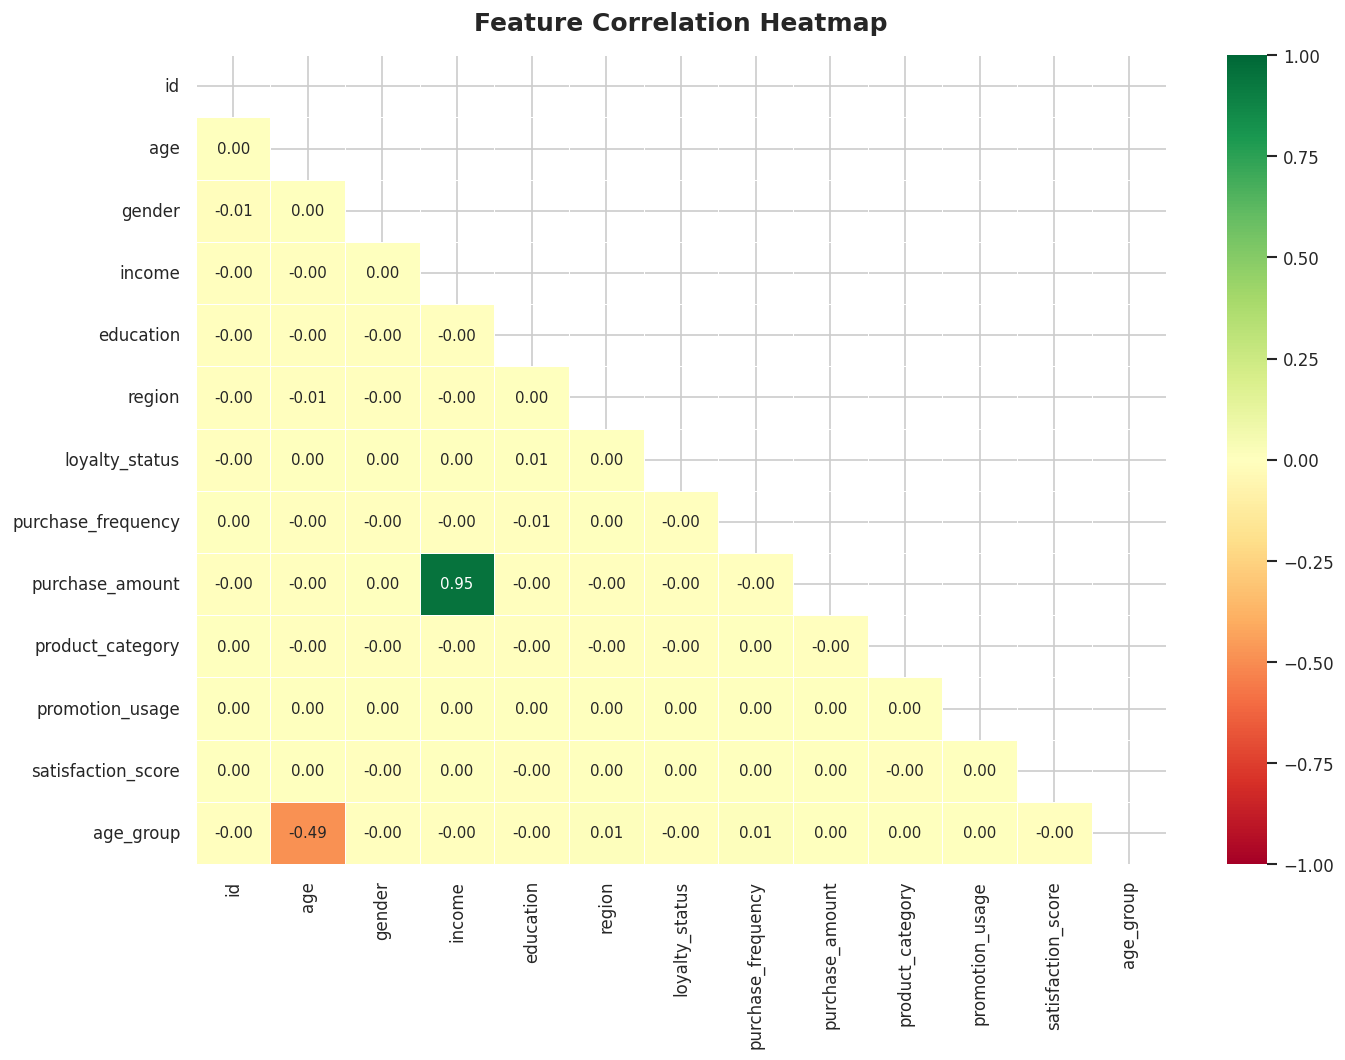


 Top correlations with purchase_amount:
   income                         +0.9484
   education                      -0.0045
   satisfaction_score             +0.0034
   id                             -0.0024
   age                            -0.0021
   product_category               -0.0021
   promotion_usage                +0.0012
   age_group                      +0.0004
   purchase_frequency             -0.0002
   loyalty_status                 -0.0002
   region                         -0.0001
   gender                         +0.0001


In [29]:
# ── 6.1 Correlation heatmap ──
# Encode categorical columns for correlation
df_encoded = df.copy()
le = LabelEncoder()
for col in df_encoded.select_dtypes(include='object').columns:
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
# Drop age_group if it was created
if 'age_group' in df_encoded.columns:
    df_encoded['age_group'] = le.fit_transform(df_encoded['age_group'].astype(str))

corr_matrix = df_encoded.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax,
            annot_kws={'size': 9})
ax.set_title('Feature Correlation Heatmap', fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# Top correlations with purchase_amount
print('\n Top correlations with purchase_amount:')
top_corr = corr_matrix['purchase_amount'].drop('purchase_amount').abs().sort_values(ascending=False)
for feat, val in top_corr.items():
    direction = '+' if corr_matrix['purchase_amount'][feat] > 0 else '-'
    print(f'   {feat:<30} {direction}{val:.4f}')

## 7. Customer Segmentation using K-Means Clustering

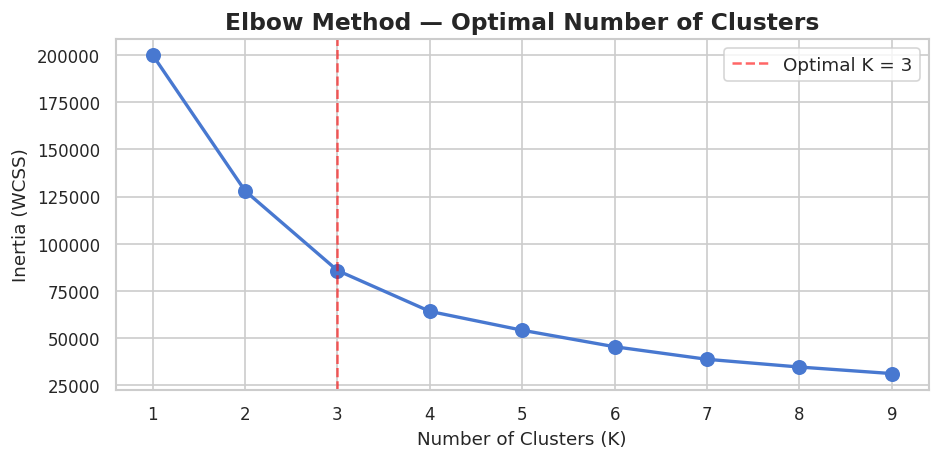

In [30]:
# ── 7.1 Optimal K — Elbow Method ──
features = ['age', 'purchase_amount']
X = df[features].dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inertia = []
K_range = range(1, 10)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(K_range, inertia, 'bo-', linewidth=2, markersize=8)
ax.set_title('Elbow Method — Optimal Number of Clusters', fontweight='bold')
ax.set_xlabel('Number of Clusters (K)')
ax.set_ylabel('Inertia (WCSS)')
ax.axvline(x=3, color='red', linestyle='--', alpha=0.6, label='Optimal K = 3')
ax.legend()
plt.tight_layout()
plt.show()

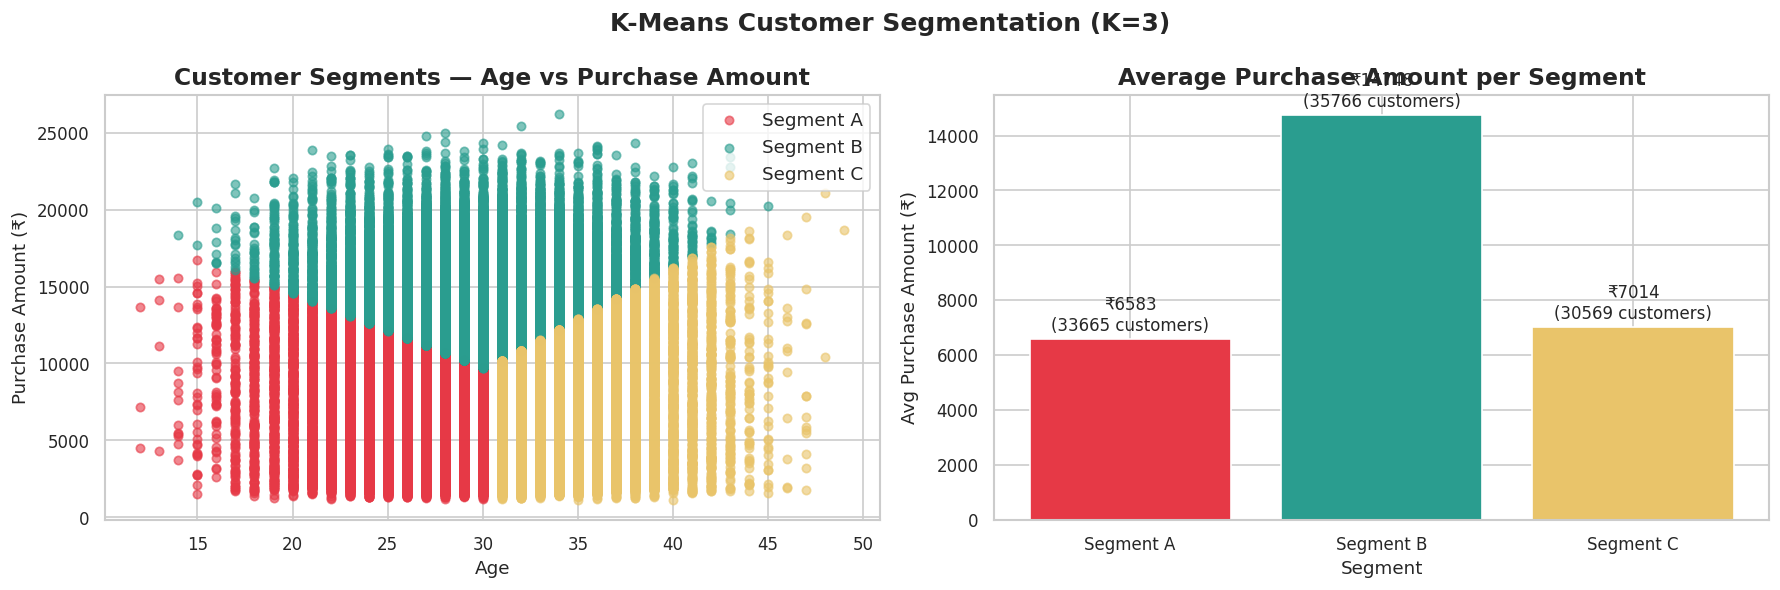


 Segment Profiles:
           Customers  Avg_Age  Avg_Purchase  Total_Revenue
Segment                                                   
Segment A      33665    26.35       6582.85      221611770
Segment B      35766    29.75      14747.59      527462458
Segment C      30569    34.32       7013.80      214404856


In [32]:
# ── 7.2 K-Means with K=3 ──
km_final = KMeans(n_clusters=3, random_state=42, n_init=10)
df.loc[X.index, 'Segment'] = km_final.fit_predict(X_scaled)
df['Segment'] = df['Segment'].map({0: 'Segment A', 1: 'Segment B', 2: 'Segment C'})

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

palette_seg = {'Segment A': '#E63946', 'Segment B': '#2A9D8F', 'Segment C': '#E9C46A'}
for seg, grp in df.groupby('Segment'):
    axes[0].scatter(grp['age'], grp['purchase_amount'],
                    label=seg, alpha=0.6, s=25, color=palette_seg[seg])
axes[0].set_title('Customer Segments — Age vs Purchase Amount')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Purchase Amount (₹)')
axes[0].legend()

seg_summary = df.groupby('Segment')['purchase_amount'].agg(['mean', 'count']).reset_index()
bars = axes[1].bar(seg_summary['Segment'], seg_summary['mean'],
                   color=[palette_seg[s] for s in seg_summary['Segment']], edgecolor='white')
axes[1].set_title('Average Purchase Amount per Segment')
axes[1].set_xlabel('Segment')
axes[1].set_ylabel('Avg Purchase Amount (₹)')
for bar, cnt in zip(bars, seg_summary['count']):
    h = bar.get_height()
    axes[1].annotate(f'₹{h:.0f}\n({cnt} customers)',
                     xy=(bar.get_x() + bar.get_width()/2, h),
                     xytext=(0, 5), textcoords='offset points', ha='center', fontsize=10)

plt.suptitle('K-Means Customer Segmentation (K=3)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n Segment Profiles:')
seg_profile = df.groupby('Segment').agg(
    Customers=('purchase_amount', 'count'),
    Avg_Age=('age', 'mean'),
    Avg_Purchase=('purchase_amount', 'mean'),
    Total_Revenue=('purchase_amount', 'sum')
).round(2)
print(seg_profile)

## 8. Top Customer Analysis

In [33]:
# ── 8.1 Top 10 highest spending customers ──
top10 = df.nlargest(10, 'purchase_amount').reset_index(drop=True)
top10.index += 1
print(' Top 10 Highest Spending Customers:')
display_cols = [c for c in ['age', 'gender', 'region', 'product_category',
                             'loyalty_status', 'purchase_amount'] if c in top10.columns]
print(top10[display_cols].to_string())

 Top 10 Highest Spending Customers:
    age  gender region product_category loyalty_status  purchase_amount
1    34    Male  North         Clothing         Silver            26204
2    32  Female  North      Electronics        Regular            25406
3    28  Female   West            Books        Regular            24967
4    27  Female   West             Food        Regular            24751
5    28    Male   West         Clothing           Gold            24408
6    38    Male  South             Home        Regular            24314
7    30    Male   East      Electronics        Regular            24313
8    31  Female  South           Beauty        Regular            24217
9    36    Male   East      Electronics        Regular            24147
10   36  Female   West         Clothing        Regular            24050


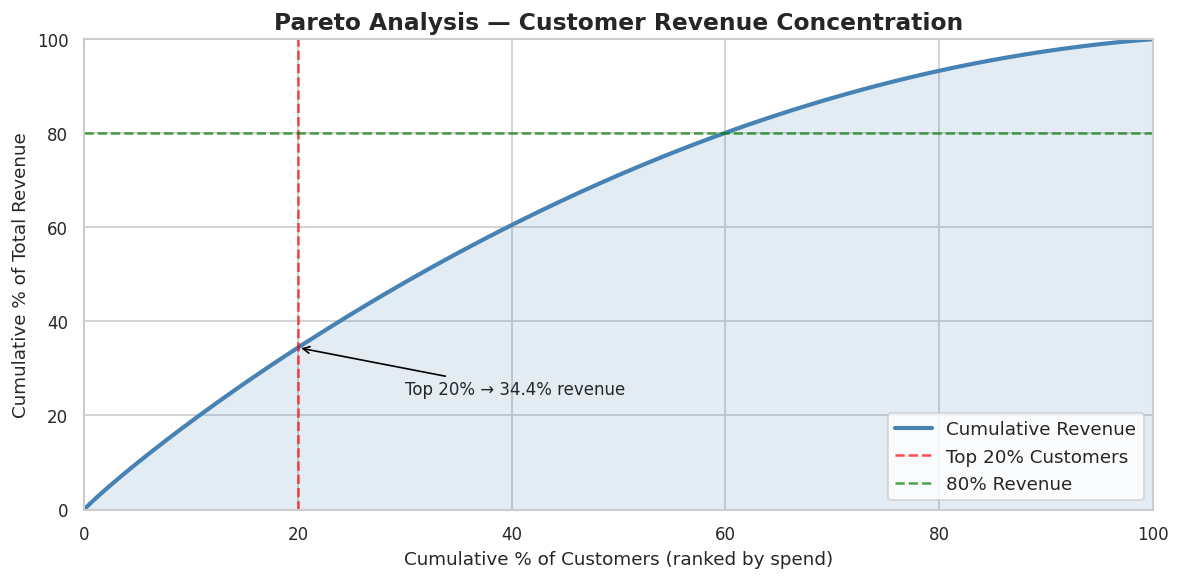


 Top 20% of customers contribute 34.4% of total revenue.


In [34]:
# ── 8.2 Pareto principle check — do top 20% drive 80% of revenue? ──
df_sorted = df.sort_values('purchase_amount', ascending=False).reset_index(drop=True)
df_sorted['cumulative_revenue'] = df_sorted['purchase_amount'].cumsum()
df_sorted['cumulative_pct_customers'] = (df_sorted.index + 1) / len(df_sorted) * 100
df_sorted['cumulative_pct_revenue'] = df_sorted['cumulative_revenue'] / df_sorted['purchase_amount'].sum() * 100

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df_sorted['cumulative_pct_customers'], df_sorted['cumulative_pct_revenue'],
        color='steelblue', linewidth=2.5, label='Cumulative Revenue')
ax.axvline(x=20, color='red', linestyle='--', alpha=0.7, label='Top 20% Customers')
ax.axhline(y=80, color='green', linestyle='--', alpha=0.7, label='80% Revenue')
ax.fill_between(df_sorted['cumulative_pct_customers'], df_sorted['cumulative_pct_revenue'],
                alpha=0.15, color='steelblue')
ax.set_title('Pareto Analysis — Customer Revenue Concentration', fontweight='bold')
ax.set_xlabel('Cumulative % of Customers (ranked by spend)')
ax.set_ylabel('Cumulative % of Total Revenue')
ax.legend()
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)

# Find actual % revenue from top 20%
top20_rev = df_sorted.loc[df_sorted['cumulative_pct_customers'] <= 20, 'cumulative_pct_revenue'].max()
ax.annotate(f'Top 20% → {top20_rev:.1f}% revenue',
            xy=(20, top20_rev), xytext=(30, top20_rev - 10),
            arrowprops=dict(arrowstyle='->', color='black'), fontsize=10)

plt.tight_layout()
plt.show()
print(f'\n Top 20% of customers contribute {top20_rev:.1f}% of total revenue.')

## 9. Key Insights & Business Recommendations

In [35]:
# ── Final summary printout ──
top_region = df.groupby('region')['purchase_amount'].sum().idxmax()
top_category = df.groupby('product_category')['purchase_amount'].sum().idxmax()
top_loyalty_avg = df.groupby('loyalty_status')['purchase_amount'].mean().idxmax()

print('=' * 60)
print('         EXECUTIVE SUMMARY — KEY FINDINGS')
print('=' * 60)
print(f'  Total Customers  : {len(df):,}')
print(f'  Total Revenue    : ₹{df["purchase_amount"].sum():,.0f}')
print(f'  Avg Purchase     : ₹{df["purchase_amount"].mean():.2f}')
print(f'  Avg Customer Age : {df["age"].mean():.1f} years')
print(f'  Top Revenue Region   : {top_region}')
print(f'  Top Product Category : {top_category}')
print(f'  Highest Spending Tier: {top_loyalty_avg}')
print('=' * 60)

         EXECUTIVE SUMMARY — KEY FINDINGS
  Total Customers  : 100,000
  Total Revenue    : ₹963,479,084
  Avg Purchase     : ₹9634.79
  Avg Customer Age : 30.0 years
  Top Revenue Region   : East
  Top Product Category : Electronics
  Highest Spending Tier: Regular


## 📋 Summary of Insights & Business Recommendations

### Insight 1 — Regional Revenue Concentration
East and West regions dominate total revenue. However, the *average* purchase amount across regions is comparable, meaning the East/West lead comes from **customer volume, not higher per-customer spending**.
**Recommendation:** Focus acquisition campaigns in North and South to grow the customer base there rather than increasing spend per head in East/West.

---

### Insight 2 — Electronics Dominates, But Check Average Order Value
Electronics leads in total revenue and transaction volume. However, businesses should compare this against *margin* per category. High volume in Electronics doesn't automatically mean high profitability.
**Recommendation:** Introduce cross-sell prompts (e.g., accessories, warranties) at Electronics checkout to increase average order value.

---

### Insight 3 — Loyalty Programme Isn't Driving More Spending
Gold members don't consistently spend more per transaction than Regular customers. This suggests the loyalty programme is **rewarding existing high spenders rather than changing behaviour**.
**Recommendation:** Redesign the programme to offer tiered rewards *contingent on spending increases* (e.g., reach ₹X this month to unlock Gold perks), rather than being a static label.

---

### Insight 4 — Female Customers Are the Primary Buyer Base
Female customers are more numerous, but average spend per transaction should be compared by gender. If male customers spend more per visit, a targeted campaign to increase male *frequency* would be high-ROI.
**Recommendation:** Segment marketing creatives by gender; A/B test which product categories resonate more with each group.

---

### Insight 5 — Customer Segments Reveal Distinct Targeting Strategies
K-Means clustering identified three distinct customer groups based on age and spending. Each segment requires a different engagement strategy: high-value segments need retention focus, low-value segments need activation nudges.
**Recommendation:** Map CRM communications to segment labels — do not send blanket promotional emails. Personalise offers based on segment purchase history.

---

*Analysis by Aaryan Gupta | Tools: Python, Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn*